In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix
)



In [ ]:

# 1. LOAD DATA


df = pd.read_csv("/content/ML Student Performance Prediction and Model Evaluation.csv")

print(df.head())
print(df.shape)
print(df.info())




  student_id  age  gender  study_hours_per_day  social_media_hours  \
0      S1000   23  Female                  0.0                 1.2   
1      S1001   20  Female                  6.9                 2.8   
2      S1002   21    Male                  1.4                 3.1   
3      S1003   23  Female                  1.0                 3.9   
4      S1004   19  Female                  5.0                 4.4   

   netflix_hours part_time_job  attendance_percentage  sleep_hours  \
0            1.1            No                   85.0          8.0   
1            2.3            No                   97.3          4.6   
2            1.3            No                   94.8          8.0   
3            1.0            No                   71.0          9.2   
4            0.5            No                   90.9          4.9   

  diet_quality  exercise_frequency parental_education_level internet_quality  \
0         Fair                   6                   Master          Average  

In [ ]:

#2. NUMERICAL & CATEGORICAL


num_cols = df.select_dtypes(include="number").columns
cat_cols = df.select_dtypes(include="object").columns

print("Numerical columns:")
print(num_cols)

print("\nCategorical columns:")
print(cat_cols)




Numerical columns:
Index(['age', 'study_hours_per_day', 'social_media_hours', 'netflix_hours',
       'attendance_percentage', 'sleep_hours', 'exercise_frequency',
       'mental_health_rating', 'exam_score'],
      dtype='object')

Categorical columns:
Index(['student_id', 'gender', 'part_time_job', 'diet_quality',
       'parental_education_level', 'internet_quality',
       'extracurricular_participation'],
      dtype='object')


In [ ]:

# 3. MISSING VALUES


print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())





Missing values:
student_id                        0
age                               0
gender                            0
study_hours_per_day               0
social_media_hours                0
netflix_hours                     0
part_time_job                     0
attendance_percentage             0
sleep_hours                       0
diet_quality                      0
exercise_frequency                0
parental_education_level         91
internet_quality                  0
mental_health_rating              0
extracurricular_participation     0
exam_score                        0
dtype: int64

Duplicate rows:
0


In [ ]:

# 4. BASIC STATISTICS


print(df.describe())




             age  study_hours_per_day  social_media_hours  netflix_hours  \
count  1000.0000           1000.00000         1000.000000    1000.000000   
mean     20.4980              3.55010            2.505500       1.819700   
std       2.3081              1.46889            1.172422       1.075118   
min      17.0000              0.00000            0.000000       0.000000   
25%      18.7500              2.60000            1.700000       1.000000   
50%      20.0000              3.50000            2.500000       1.800000   
75%      23.0000              4.50000            3.300000       2.525000   
max      24.0000              8.30000            7.200000       5.400000   

       attendance_percentage  sleep_hours  exercise_frequency  \
count            1000.000000  1000.000000         1000.000000   
mean               84.131700     6.470100            3.042000   
std                 9.399246     1.226377            2.025423   
min                56.000000     3.200000            0.

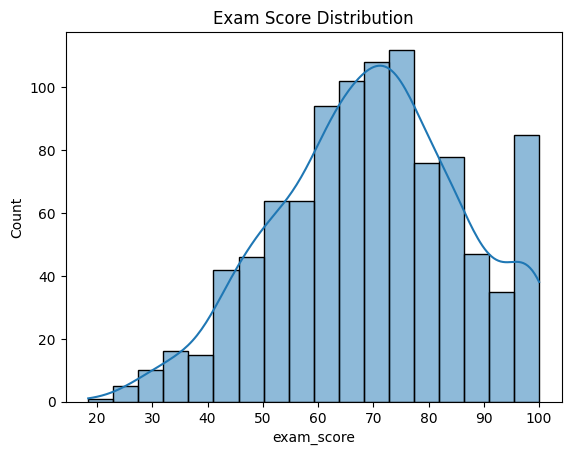

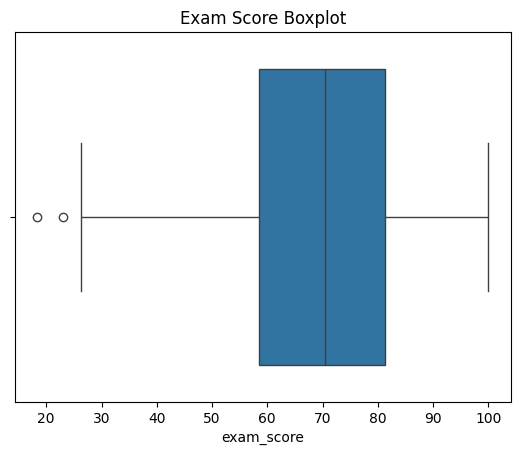

In [ ]:

# 5. EXAM SCORE DISTRIBUTION


sns.histplot(df["exam_score"], kde=True)
plt.title("Exam Score Distribution")
plt.show()

sns.boxplot(x=df["exam_score"])
plt.title("Exam Score Boxplot")
plt.show()



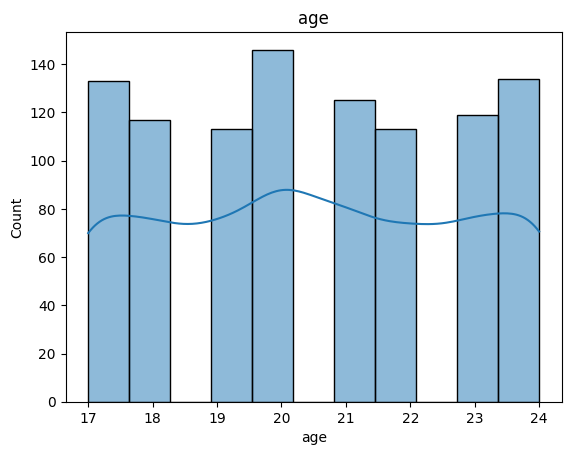

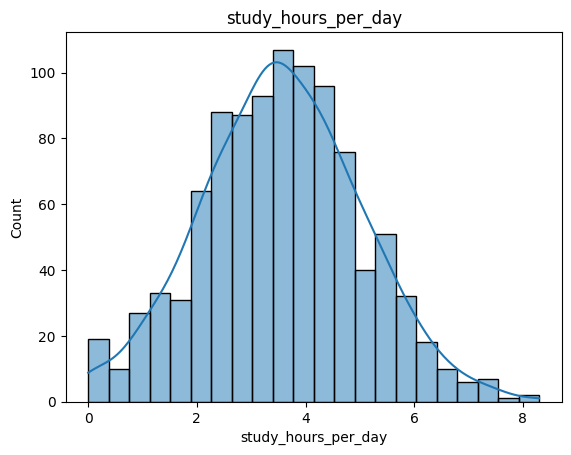

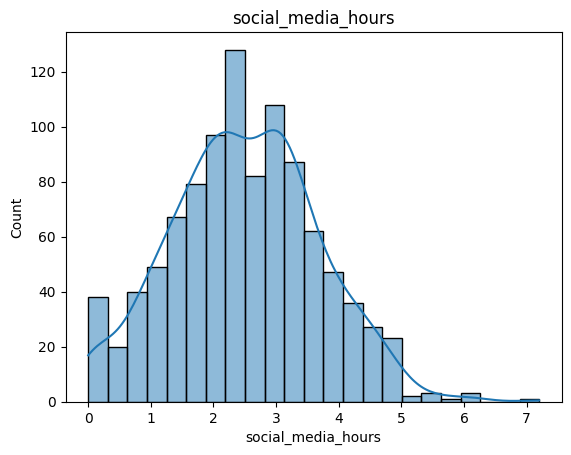

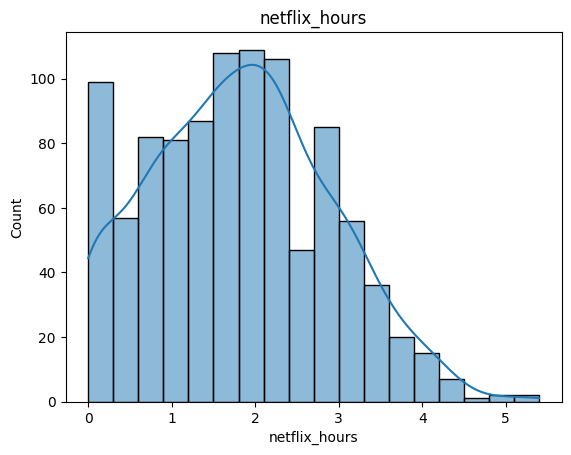

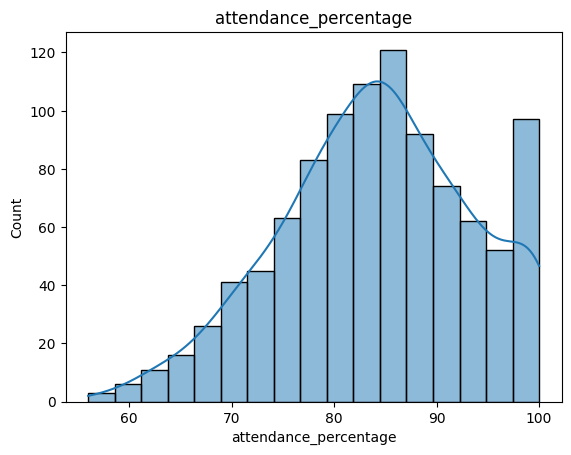

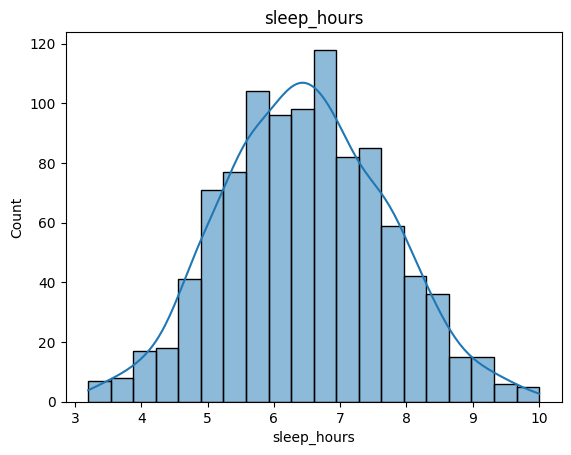

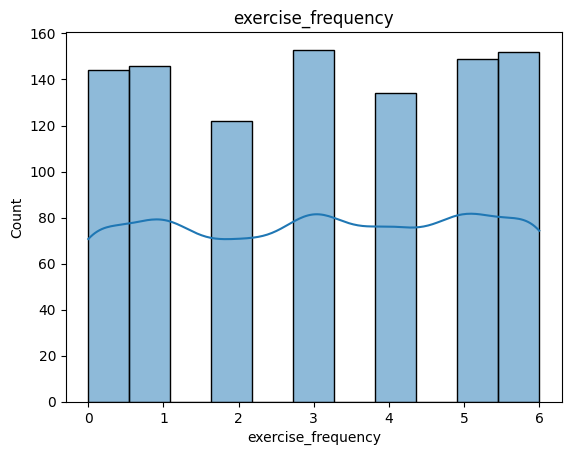

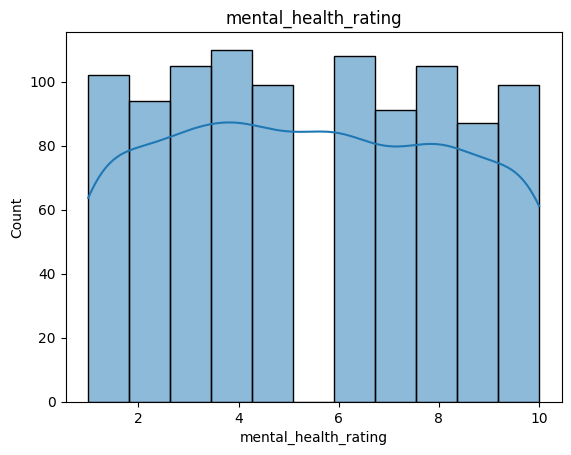

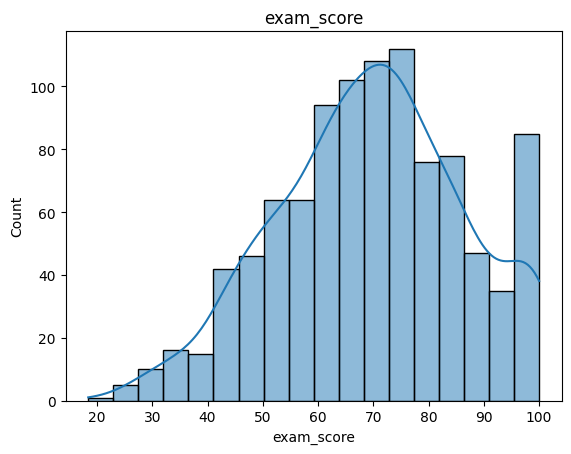

In [ ]:


# 6. NUMERICAL DISTRIBUTIONS


for col in num_cols:
    sns.histplot(df[col], kde=True)
    plt.title(col)
    plt.show()




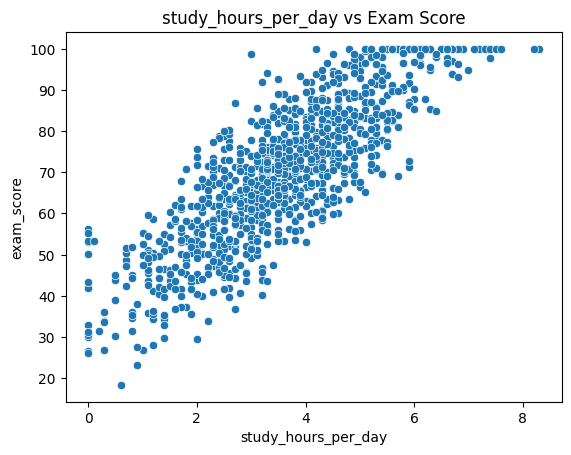

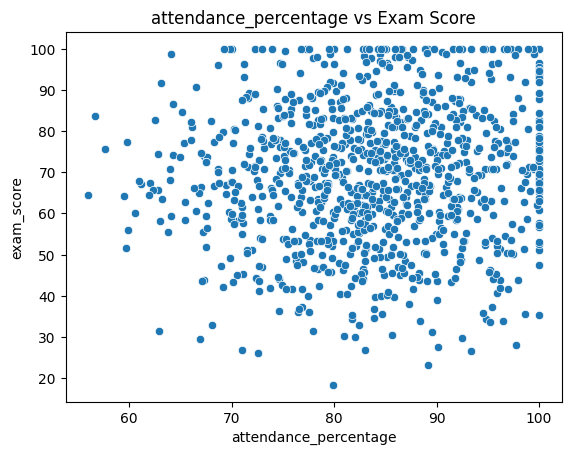

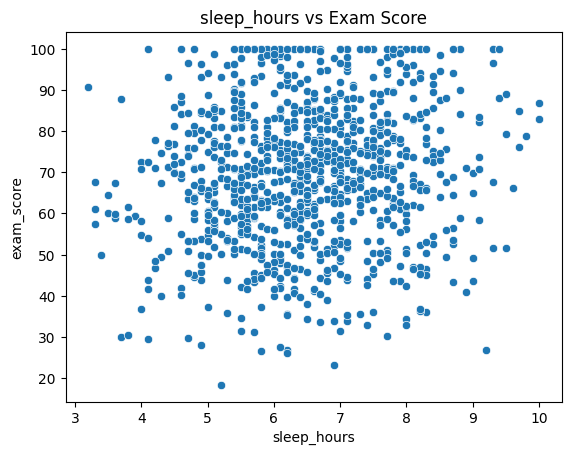

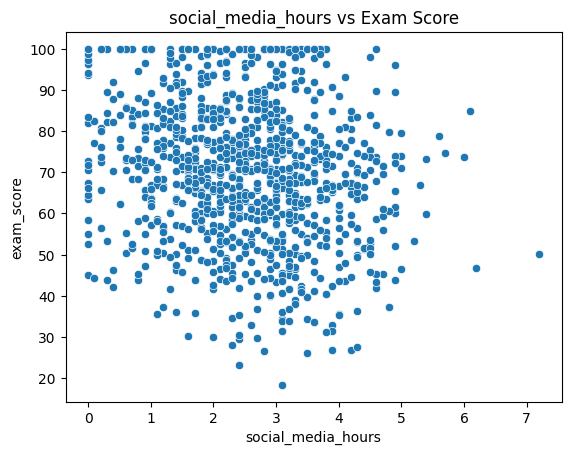

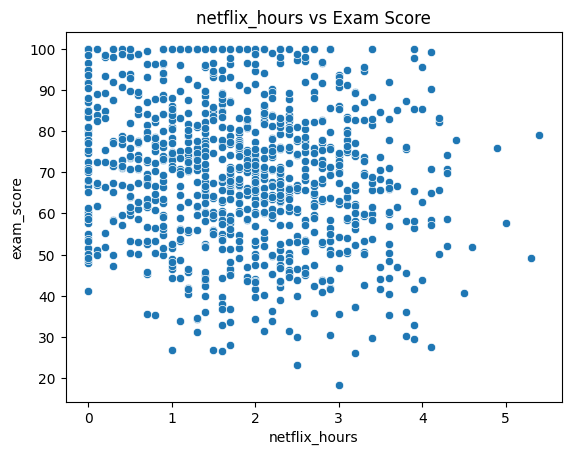

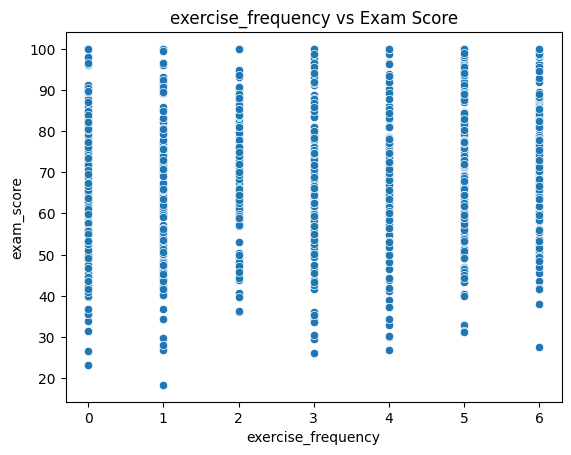

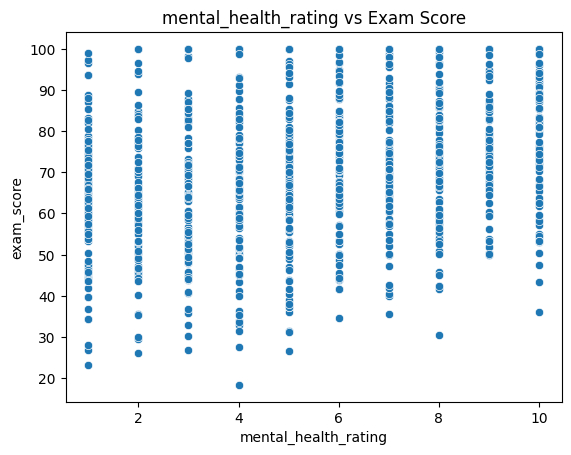

In [ ]:


# 8. RELATIONSHIP WITH EXAM SCORE


features = [
    "study_hours_per_day",
    "attendance_percentage",
    "sleep_hours",
    "social_media_hours",
    "netflix_hours",
    "exercise_frequency",
    "mental_health_rating"
]

for col in features:
    sns.scatterplot(data=df, x=col, y="exam_score")
    plt.title(col + " vs Exam Score")
    plt.show()




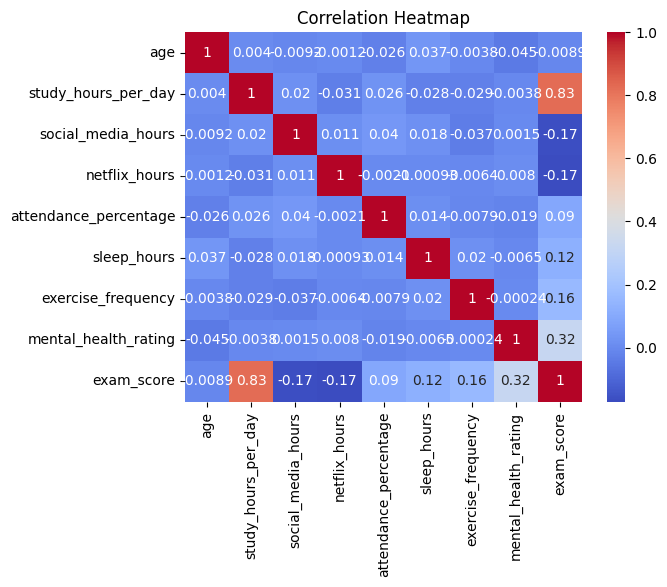


Correlation with exam_score:
exam_score               1.000000
study_hours_per_day      0.825419
mental_health_rating     0.321523
exercise_frequency       0.160107
sleep_hours              0.121683
attendance_percentage    0.089836
age                     -0.008907
social_media_hours      -0.166733
netflix_hours           -0.171779
Name: exam_score, dtype: float64


In [ ]:

# 9. CORRELATION


corr = df.select_dtypes(include="number").corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

print("\nCorrelation with exam_score:")
print(corr["exam_score"].sort_values(ascending=False))




In [ ]:

# 10. OUTLIERS USING IQR


for col in num_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[
        (df[col] < lower) |
        (df[col] > upper)
    ]

    print(col, "Outliers:", len(outliers))




age Outliers: 0
study_hours_per_day Outliers: 7
social_media_hours Outliers: 5
netflix_hours Outliers: 4
attendance_percentage Outliers: 3
sleep_hours Outliers: 2
exercise_frequency Outliers: 0
mental_health_rating Outliers: 0
exam_score Outliers: 2


In [ ]:

# 11. PREPARE DATA


# Remove student ID
df = df.drop("student_id", axis=1)

# Fill missing categorical values
df["parental_education_level"] = df[
    "parental_education_level"
].fillna("Unknown")

# Convert categorical columns into numbers
df = pd.get_dummies(
    df,
    drop_first=True
)




In [ ]:

# 12. LINEAR REGRESSION


X = df.drop("exam_score", axis=1)

y = df["exam_score"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = LinearRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)




In [ ]:

# 13. REGRESSION RESULTS


print("\nREGRESSION RESULTS")

print("MAE:",
      mean_absolute_error(y_test, y_pred))

print("MSE:",
      mean_squared_error(y_test, y_pred))

print("RMSE:",
      np.sqrt(mean_squared_error(y_test, y_pred)))

print("R2 Score:",
      r2_score(y_test, y_pred))





REGRESSION RESULTS
MAE: 4.189311054627598
MSE: 26.476236454969186
RMSE: 5.1455064332842095
R2 Score: 0.8967502640380202


In [ ]:

# 14. PASS / FAIL


df["pass_fail"] = np.where(
    df["exam_score"] >= 50,
    "Pass",
    "Fail"
)

print("\nPass/Fail:")
print(df["pass_fail"].value_counts())





Pass/Fail:
pass_fail
Pass    869
Fail    131
Name: count, dtype: int64


In [ ]:
# 15. CLASSIFICATION


X = df.drop(
    ["exam_score", "pass_fail"],
    axis=1
)

y = df["pass_fail"]

y = y.map({
    "Fail": 0,
    "Pass": 1
})


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# Logistic Regression
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)




In [ ]:

# 16. CLASSIFICATION RESULTS


print("\nCLASSIFICATION RESULTS")

print("Accuracy:",
      accuracy_score(y_test, y_pred))

print("Precision:",
      precision_score(y_test, y_pred))

print("Recall:",
      recall_score(y_test, y_pred))

print("F1 Score:",
      f1_score(y_test, y_pred))





CLASSIFICATION RESULTS
Accuracy: 0.95
Precision: 0.9659090909090909
Recall: 0.9770114942528736
F1 Score: 0.9714285714285714


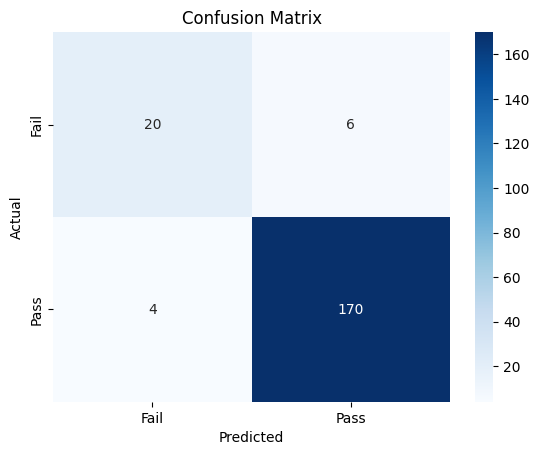

In [ ]:

# 17. CONFUSION MATRIX


cm = confusion_matrix(y_test, y_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Fail", "Pass"],
    yticklabels=["Fail", "Pass"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()